# Feature engineering

## Load the dataset

Load the dataset processed in the previous notebook.

In [131]:
import pandas as pd

exploratory_df = pd.read_csv("dataset/processed/exploratory-packages-highest-ctr.csv")
confirmatory_df = pd.read_csv("dataset/processed/confirmatory-packages-highest-ctr.csv")
holdout_df = pd.read_csv("dataset/processed/holdout-packages-highest-ctr.csv")

exploratory_df.head()

,package_id,created_at,test_week,clickability_test_id,headline,eyecatcher_id,impressions,clicks,ctr,first_place,winner,is_highest_ctr
0,0,2014-11-20 06:43:16.005,201446,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,546d6fa19ad54eec8d00002d,3052,150,0.049148,True,True,True
1,1,2014-11-20 06:43:44.646,201446,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,546d6fa19ad54eec8d00002d,3033,122,0.040224,False,False,False
2,2,2014-11-20 06:44:59.804,201446,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,546d6fa19ad54eec8d00002d,3092,110,0.035576,False,False,False
3,3,2014-11-20 06:54:36.335,201446,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,546bc55335992b86c8000043,3526,90,0.025525,False,False,False
4,4,2014-11-20 06:54:57.878,201446,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,546d900426714cd2dd00002e,3506,120,0.034227,True,False,True


## Named Entity Recognition

I'll use SpaCy to extract the named entities from the headlines. I want more specifically extract if the headline mentions a person, an organization or a geographic entity.

I also verify if the headline mentions a monetary amount.

In [132]:
import spacy

print("Download spaCy model")
spacy.cli.download("en_core_web_md")
nlp = spacy.load("en_core_web_md")

Download spaCy model
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 61.7 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [133]:
def extract_named_entities(df: pd.DataFrame) -> pd.DataFrame:
    texts = df["headline"].fillna("").tolist()

    person_counts, org_counts, gpe_counts = [], [], []
    has_person, has_org, has_gpe, has_money = [], [], [], []

    # I had performance issues doing it one-by-one. I found this pipe feature which improved the performance by 4x
    for doc in nlp.pipe(texts, batch_size=256, n_process=4):
        person_count = sum(1 for ent in doc.ents if ent.label_ == "PERSON")
        org_count = sum(1 for ent in doc.ents if ent.label_ == "ORG")
        gpe_count = sum(1 for ent in doc.ents if ent.label_ == "GPE")
        money_count = sum(1 for ent in doc.ents if ent.label_ == "MONEY")

        person_counts.append(person_count)
        org_counts.append(org_count)
        gpe_counts.append(gpe_count)

        has_person.append(person_count > 0)
        has_org.append(org_count > 0)
        has_gpe.append(gpe_count > 0)
        has_money.append(money_count > 0)

    df["headline_num_persons"] = person_counts
    df["headline_num_orgs"] = org_counts
    df["headline_num_gpes"] = gpe_counts

    df["headline_has_person"] = has_person
    df["headline_has_org"] = has_org
    df["headline_has_gpe"] = has_gpe
    df["headline_has_money"] = has_money

    return df

exploratory_df = extract_named_entities(exploratory_df)

exploratory_df[["headline", "headline_num_persons", "headline_num_orgs", "headline_num_gpes", "headline_has_person", "headline_has_org", "headline_has_gpe", "headline_has_money"]][:20]


,headline,headline_num_persons,headline_num_orgs,headline_num_gpes,headline_has_person,headline_has_org,headline_has_gpe,headline_has_money
0,They're Being Called 'Walmart's Worst Nightmar...,0,0,0,False,False,False,False
1,They're Being Called 'Walmart's Worst Nightmar...,0,0,0,False,False,False,False
2,They're Being Called 'Walmart's Worst Nightmar...,0,0,0,False,False,False,False
3,This Is What Sexism Against Men Sounds Like,0,0,0,False,False,False,False
4,This Is What Sexism Against Men Sounds Like,0,0,0,False,False,False,False
5,This Is What Sexism Against Men Sounds Like,0,0,0,False,False,False,False
6,This Is What Sexism Against Men Sounds Like,0,0,0,False,False,False,False
7,This Is What Sexism Against Men Sounds Like,0,0,0,False,False,False,False
8,This Is What Sexism Against Men Sounds Like,0,0,0,False,False,False,False
9,This Is What Sexism Against Men Sounds Like,0,0,0,False,False,False,False


Doing the same for the confirmatory and holdout datasets.

In [134]:
print("Processing confirmatory dataset")
confirmatory_df = extract_named_entities(confirmatory_df)
print("Processing holdout dataset")
holdout_df = extract_named_entities(holdout_df)

Processing confirmatory dataset


Processing holdout dataset


### Famous people mentioned in the headline

I obtained this idea from the Nate Matias meta analysis and a proposal made in his course:

[Github - Lecture 15 - Asking Questions of the Upworthy Archive](https://github.com/natematias/design-governance-experiments/blob/master/2020/lectures/Lecture%2015%20-%20Asking%20Questions%20of%20the%20Upworthy%20Archive.pdf)

First I'll extract and print the names of persons identified in the headlines.

In [135]:
texts = exploratory_df["headline"].fillna("").tolist()

person_names = set()

for doc in nlp.pipe(texts, batch_size=256, n_process=4):
    persons = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
    person_names.update(persons)

print(f"{len(person_names)} unique persons found in the headlines")
print(f"Persons found: {', '.join(person_names)}")


779 unique persons found in the headlines
Persons found: This Mind-Blowing Fact, Jennifer Aniston, Dale, Zombie Brains, Abraham Lincoln, Eating Healthy Is Challenging As, This Guy Talked Back, Rosario Dawson, James Bond, Ronald McDonald, George Lopez, Stormie, Dan Quayle, L.O.V.E., Bullshit, Huggles Required, These Black Girls Are Coming For Your Throne, Introvert, This Guy, John Oliver Expected, Janay Rice Ought, Hitler, Sam Pepper Lost A Lot Over His Sexual Assault 'Antics, Moms Rock, This Innocent Teen Finally Gets To, Newly Married, Beyonce, Argumentative Guy, Mary Poppins Impression, Wait'll, This Beyoncé Gif, Leonardo DiCaprio, Deep Throat', Renegade Bees, Mighty Thirsty, Beyoncé Be, Samuel L. Jackson Just, Glen Close, Cleopatra, Joan Rivers Paved The Way For Countless Female Comics While Making Everyone Laugh, Bob Dylan, This Girl Grows, Angelina Jolie, Tess Munster, Steven Spielberg X, Obama, Thomas Jefferson, Hank Green Goes Up Against A Corporate Suit To Debate An Unsexy, Oba

In [136]:
print("Persons found:")
for name in person_names:
    print(name)

Persons found:
This Mind-Blowing Fact
Jennifer Aniston
Dale
Zombie Brains
Abraham Lincoln
Eating Healthy Is Challenging As
This Guy Talked Back
Rosario Dawson
James Bond
Ronald McDonald
George Lopez
Stormie
Dan Quayle
L.O.V.E.
Bullshit
Huggles Required
These Black Girls Are Coming For Your Throne
Introvert
This Guy
John Oliver Expected
Janay Rice Ought
Hitler
Sam Pepper Lost A Lot Over His Sexual Assault 'Antics
Moms Rock
This Innocent Teen Finally Gets To
Newly Married
Beyonce
Argumentative Guy
Mary Poppins Impression
Wait'll
This Beyoncé Gif
Leonardo DiCaprio
Deep Throat'
Renegade Bees
Mighty Thirsty
Beyoncé Be
Samuel L. Jackson Just
Glen Close
Cleopatra
Joan Rivers Paved The Way For Countless Female Comics While Making Everyone Laugh
Bob Dylan
This Girl Grows
Angelina Jolie
Tess Munster
Steven Spielberg X
Obama
Thomas Jefferson
Hank Green Goes Up Against A Corporate Suit To Debate An Unsexy
Obama Shames
Adrian Peterson
Billy Joel
The Simple Brilliance Of His Idea Is Sweet
Lesbians
S

I was planning to verify if the persons found are famous by going to Wikipedia, but doing a quick review I see almost every name identified is already a famous person.

In many cases, segments of words are identified as persons, like "Eating Healthy Is Challenging As", but the number of those errors is very low.

### Review results

<Axes: >

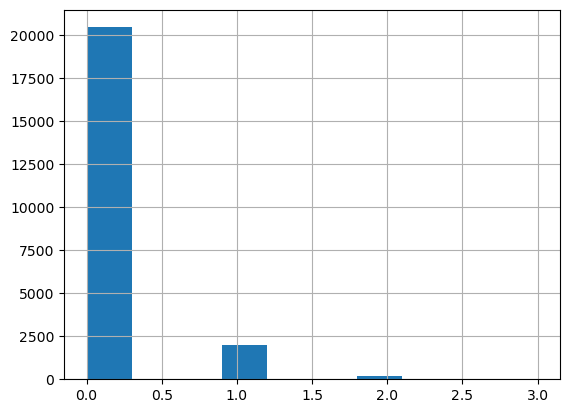

In [137]:
exploratory_df["headline_num_persons"].hist()

<Axes: >

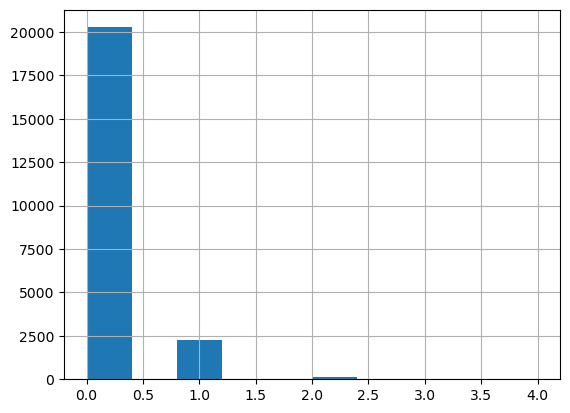

In [138]:
exploratory_df["headline_num_orgs"].hist()

<Axes: >

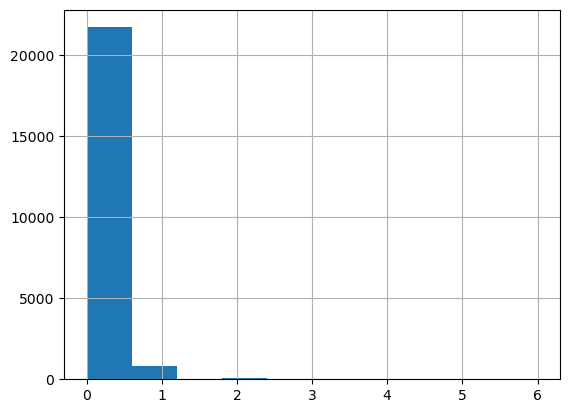

In [139]:
exploratory_df["headline_num_gpes"].hist()

In [140]:
print(exploratory_df["headline_has_person"].value_counts())
print(exploratory_df["headline_has_org"].value_counts())
print(exploratory_df["headline_has_gpe"].value_counts())

headline_has_person
False    20452
True      2214
Name: count, dtype: int64
headline_has_org
False    20271
True      2395
Name: count, dtype: int64
headline_has_gpe
False    21725
True       941
Name: count, dtype: int64


## Other features

I'll also extract some simple features that may be useful for the prediction:
- starts_with_verb
- starts_with_pronoun
- starts_with_number
- num_pronouns
- num_chars
- num_tokens
- avg_token_len
- ends_with_qmark
- ends_with_exclaim
- has_quote
- has_all_caps_word
- num_nouns
- num_verbs
- num_adjs
- num_advs
- num_pronouns

At worst they won't hurt.

In [141]:
import numpy as np

def extract_other_features(df: pd.DataFrame) -> pd.DataFrame:
    texts = df["headline"].fillna("").tolist()
    feature_rows = []

    for doc in nlp.pipe(texts, batch_size=256, n_process=4):
        tokens = [t for t in doc if not t.is_space]
        content_tokens = [t for t in tokens if not t.is_punct]
        first_token = content_tokens[0] if content_tokens else None

        # First token is a verb or an auxiliary
        starts_with_verb = (first_token is not None and first_token.pos_ in ("VERB", "AUX"))
        # First token is a pronoun
        starts_with_pronoun = first_token is not None and first_token.pos_ == "PRON"
        # First token is a number
        starts_with_number = (first_token is not None and (first_token.like_num or first_token.pos_ == "NUM"))
        # Calculate length
        text = doc.text
        num_chars = len(text)
        num_tokens = len(tokens)
        avg_token_len = float(sum(len(t.text) for t in tokens)) / num_tokens if num_tokens > 0 else 0.0

        stripped = text.rstrip()
        ends_with_qmark = stripped.endswith("?")
        ends_with_exclaim = stripped.endswith("!")
        quote_chars = ['"', "'", "“", "”", "‘", "’"]
        has_quote = any(ch in text for ch in quote_chars)

        has_all_caps_word = any(tok.is_alpha and tok.text.isupper() and len(tok.text) > 1 for tok in tokens)

        num_nouns = sum(t.pos_ in ("NOUN", "PROPN") for t in tokens)
        num_verbs = sum(t.pos_ in ("VERB", "AUX") for t in tokens)
        num_adjs = sum(t.pos_ == "ADJ" for t in tokens)
        num_advs = sum(t.pos_ == "ADV" for t in tokens)
        num_pronouns = sum(t.pos_ == "PRON" for t in tokens)
        
        feature_rows.append(
            {
                "starts_with_verb": starts_with_verb,
                "starts_with_pronoun": starts_with_pronoun,
                "starts_with_number": starts_with_number,
                "num_pronouns": num_pronouns,
                "num_chars": num_chars,
                "num_tokens": num_tokens,
                "avg_token_len": avg_token_len,
                "ends_with_qmark": ends_with_qmark,
                "ends_with_exclaim": ends_with_exclaim,
                "has_quote": has_quote,
                "has_all_caps_word": has_all_caps_word,
                "num_nouns": num_nouns,
                "num_verbs": num_verbs,
                "num_adjs": num_adjs,
                "num_advs": num_advs,
            }
        )

    features = pd.DataFrame(feature_rows, index=df.index)
    df = pd.concat([df, features], axis=1)
    return df

exploratory_df = extract_other_features(exploratory_df)

exploratory_df[[
    "headline",
    "starts_with_verb",
    "starts_with_pronoun",
    "starts_with_number",
    "num_pronouns",
    "num_chars",
    "num_tokens",
    "avg_token_len",
    "ends_with_qmark",
    "ends_with_exclaim",
    "has_quote",
    "has_all_caps_word",
    "num_nouns",
    "num_verbs",
    "num_adjs",
    "num_advs",
]].head()

,headline,starts_with_verb,starts_with_pronoun,starts_with_number,num_pronouns,num_chars,num_tokens,avg_token_len,ends_with_qmark,ends_with_exclaim,has_quote,has_all_caps_word,num_nouns,num_verbs,num_adjs,num_advs
0,They're Being Called 'Walmart's Worst Nightmar...,False,True,False,3,84,21,3.428571,False,False,True,False,3,5,1,1
1,They're Being Called 'Walmart's Worst Nightmar...,False,True,False,3,84,21,3.428571,False,False,True,False,3,5,1,1
2,They're Being Called 'Walmart's Worst Nightmar...,False,True,False,3,84,21,3.428571,False,False,True,False,3,5,1,1
3,This Is What Sexism Against Men Sounds Like,False,True,False,2,43,8,4.500000,False,False,False,False,2,2,0,0
4,This Is What Sexism Against Men Sounds Like,False,True,False,2,43,8,4.500000,False,False,False,False,2,2,0,0


Apply the same to the confirmatory and holdout datasets.

In [142]:
confirmatory_df = extract_other_features(confirmatory_df)
holdout_df = extract_other_features(holdout_df)

## Sentence Structure Analysis

### Identify if the sentence has an imperative style

In [143]:
def has_imperative_style_doc(doc) -> bool:
    # Get the root of the sentence
    roots = [t for t in doc if t.dep_ == "ROOT"]
    for root in roots:
        # If the verb is in simple tense
        if root.pos_ == "VERB" and root.tag_ == "VB":
            # If no subject token has this verb as the dependency
            if not any(t.head == root and t.dep_ in ["nsubj", "nsubjpass", "csubj"] for t in doc):
                return True
    return False

def extract_imperative_style(df: pd.DataFrame) -> pd.DataFrame:
    texts = df["headline"].fillna("").tolist()

    imperative_styles = []
    for doc in nlp.pipe(texts, batch_size=256, n_process=4):
        imperative_styles.append(has_imperative_style_doc(doc))

    df["headline_imperative_verb"] = imperative_styles
    return df

exploratory_df = extract_imperative_style(exploratory_df)

In [144]:
print(exploratory_df["headline_imperative_verb"].value_counts())

headline_imperative_verb
False    20123
True      2543
Name: count, dtype: int64


Apply the same to the confirmatory and holdout datasets.

In [145]:
confirmatory_df = extract_imperative_style(confirmatory_df)
holdout_df = extract_imperative_style(holdout_df)

I tried to use SpaCy "mood" attribute which should return "Imp" if it detects an imperative sentence, but it didn't find it for any of the sentences.

### Identify if the headline has a word to incentivize curiosity

The words "why", "what", "how", "this", "these", "secrets" could be related to curiosity. I will analyze if the headline contains not just one of these words, but if it contains a word that is near to those using embeddings generated by the SpaCy model.

In [146]:
CURIOSITY_WORDS = ["why", "what", "how", "this", "these", "secrets"]
curiosity_embeddings = { word: nlp(word) for word in CURIOSITY_WORDS }

INTENSITY_WORDS = ["very", "really", "incredibly", "so", "absolutely"]
intensity_embeddings = { word: nlp(word) for word in INTENSITY_WORDS }

def extract_curiosity_and_intensity_features(df: pd.DataFrame) -> pd.DataFrame:
    texts = df["headline"].fillna("").tolist()

    has_curiosity_word = []
    curiosity_similarities = []
    has_intensity_word = []
    intensity_similarities = []

    for doc in nlp.pipe(texts, batch_size=256):
        text = doc.text

        # exact match check
        has_curiosity_word.append(any(word in text for word in CURIOSITY_WORDS))
        has_intensity_word.append(any(word in text for word in INTENSITY_WORDS))

        # semantic similarity to curiosity words
        curiosity_sims = [doc.similarity(emb_doc) for emb_doc in curiosity_embeddings.values()]
        curiosity_max_sim = max(curiosity_sims) if curiosity_sims else 0.0

        curiosity_similarities.append(curiosity_max_sim)

        intensity_sims = [doc.similarity(emb_doc) for emb_doc in intensity_embeddings.values()]
        intensity_max_sim = max(intensity_sims) if intensity_sims else 0.0
        intensity_similarities.append(intensity_max_sim)

    df["headline_has_curiosity_word"] = has_curiosity_word
    df["headline_curiosity_similarity"] = curiosity_similarities
    df["headline_has_intensity_word"] = has_intensity_word
    df["headline_intensity_similarity"] = intensity_similarities

    return df

exploratory_df = extract_curiosity_and_intensity_features(exploratory_df)

print(exploratory_df["headline_has_curiosity_word"].value_counts())
print(exploratory_df["headline_curiosity_similarity"].value_counts())
print(exploratory_df["headline_has_intensity_word"].value_counts())
print(exploratory_df["headline_intensity_similarity"].value_counts())
exploratory_df[["headline", "headline_has_curiosity_word", "headline_curiosity_similarity", "headline_has_intensity_word", "headline_intensity_similarity"]][:20]


headline_has_curiosity_word
False    21537
True      1129
Name: count, dtype: int64
headline_curiosity_similarity
0.827728    22
0.868692    21
0.729621    20
0.872859    19
0.865859    19
            ..
0.891116     1
0.778608     1
0.742214     1
0.737442     1
0.858629     1
Name: count, Length: 12308, dtype: int64
headline_has_intensity_word
False    19539
True      3127
Name: count, dtype: int64
headline_intensity_similarity
0.827728    22
0.868692    21
0.729621    20
0.872859    19
0.865859    19
            ..
0.891116     1
0.778608     1
0.742214     1
0.737442     1
0.858629     1
Name: count, Length: 12308, dtype: int64


,headline,headline_has_curiosity_word,headline_curiosity_similarity,headline_has_intensity_word,headline_intensity_similarity
0,They're Being Called 'Walmart's Worst Nightmar...,False,0.914015,False,0.914015
1,They're Being Called 'Walmart's Worst Nightmar...,False,0.914015,False,0.914015
2,They're Being Called 'Walmart's Worst Nightmar...,False,0.914015,False,0.914015
3,This Is What Sexism Against Men Sounds Like,False,0.847070,False,0.847070
4,This Is What Sexism Against Men Sounds Like,False,0.847070,False,0.847070
5,This Is What Sexism Against Men Sounds Like,False,0.847070,False,0.847070
6,This Is What Sexism Against Men Sounds Like,False,0.847070,False,0.847070
7,This Is What Sexism Against Men Sounds Like,False,0.847070,False,0.847070
8,This Is What Sexism Against Men Sounds Like,False,0.847070,False,0.847070
9,This Is What Sexism Against Men Sounds Like,False,0.847070,False,0.847070


Apply the same to the confirmatory and holdout datasets.

In [147]:
confirmatory_df = extract_curiosity_and_intensity_features(confirmatory_df)
holdout_df = extract_curiosity_and_intensity_features(holdout_df)

/var/folders/fw/s4mlw4vx2hx944qtl0q1vcfm0000gn/T/ipykernel_18817/3691462791.py:23: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  curiosity_sims = [doc.similarity(emb_doc) for emb_doc in curiosity_embeddings.values()]
/var/folders/fw/s4mlw4vx2hx944qtl0q1vcfm0000gn/T/ipykernel_18817/3691462791.py:28: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  intensity_sims = [doc.similarity(emb_doc) for emb_doc in intensity_embeddings.values()]


## Sentiment Analysis

To do sentiment analysis I'll use the VADER sentiment analysis tool from the NLTK library.

I analyzed the use of VADER vs LWIC method. The second one is motly based on a sentiment dictionary, while VADER looks at punctuation and word context.

VADER is supposed to work better with social media and short text in general. LWIC is expected to be more accurate for longer text.

The material "Negativity drives online news consumption (2023)" uses LWIC to analyze the sentiment of the headlines.

The paper "Headline sentiment and topic effect on online user engagement (2021)" uses TextBlob for sentiment analysis. Based on the research of how this method works, it may also be more accurate for longer texts.

In [148]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sentiment_analyzer = SentimentIntensityAnalyzer()

# Apply VADER to each headline
sentiment_df = exploratory_df['headline'].apply(sentiment_analyzer.polarity_scores).apply(pd.Series)
exploratory_df = pd.concat([exploratory_df, sentiment_df], axis=1)

exploratory_df[["headline", "neg", "neu", "pos", "compound"]].describe()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/damiancalabresi/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,neg,neu,pos,compound
count,22666.000000,22666.000000,22666.000000,22666.000000
mean,0.098907,0.785851,0.115244,0.033755
std,0.121709,0.156674,0.131209,0.439671
min,0.000000,0.182000,0.000000,-0.948500
25%,0.000000,0.679000,0.000000,-0.296000
50%,0.000000,0.794000,0.095000,0.000000
75%,0.179000,0.896000,0.199000,0.401900
max,0.718000,1.000000,0.818000,0.951700


The mean for compound is 0.05, which means that the sentiment is mostly neutral. The variance is high but not too much. Sentiment can still be considered.

In [149]:
exploratory_df[["headline", "neg", "neu", "pos", "compound"]].head()

,headline,neg,neu,pos,compound
0,They're Being Called 'Walmart's Worst Nightmar...,0.218,0.479,0.303,0.1531
1,They're Being Called 'Walmart's Worst Nightmar...,0.218,0.479,0.303,0.1531
2,They're Being Called 'Walmart's Worst Nightmar...,0.218,0.479,0.303,0.1531
3,This Is What Sexism Against Men Sounds Like,0.000,0.737,0.263,0.3612
4,This Is What Sexism Against Men Sounds Like,0.000,0.737,0.263,0.3612


Apply the same to the confirmatory and holdout datasets.

In [150]:
sentiment_df = confirmatory_df['headline'].apply(sentiment_analyzer.polarity_scores).apply(pd.Series)
confirmatory_df = pd.concat([confirmatory_df, sentiment_df], axis=1)

holdout_sentiment_df = holdout_df['headline'].fillna("").astype(str).apply(sentiment_analyzer.polarity_scores).apply(pd.Series)
holdout_df = pd.concat([holdout_df, holdout_sentiment_df], axis=1)


## Dataset related features



In [151]:
exploratory_df["created_at"] = pd.to_datetime(exploratory_df["created_at"], format="mixed")
confirmatory_df["created_at"] = pd.to_datetime(confirmatory_df["created_at"], format="mixed")
holdout_df["created_at"] = pd.to_datetime(holdout_df["created_at"], format="mixed")

# Day of the week
exploratory_df["created_at_dayofweek"] = exploratory_df["created_at"].dt.dayofweek
confirmatory_df["created_at_dayofweek"] = confirmatory_df["created_at"].dt.dayofweek
holdout_df["created_at_dayofweek"] = holdout_df["created_at"].dt.dayofweek

# Hour of the day
exploratory_df["created_at_hourofday"] = exploratory_df["created_at"].dt.hour
confirmatory_df["created_at_hourofday"] = confirmatory_df["created_at"].dt.hour
holdout_df["created_at_hourofday"] = holdout_df["created_at"].dt.hour


Each test has a number of packages, could be 2, 3, 4, etc. A given package is competing with the other packages in the test. This will be important to calculate the probability of winning the competition in a random scenario.

I'll add to each package the number of other packages in the test.




In [152]:
exploratory_df["test_group_size"] = exploratory_df.groupby("clickability_test_id")["clickability_test_id"].transform("size")
confirmatory_df["test_group_size"] = confirmatory_df.groupby("clickability_test_id")["clickability_test_id"].transform("size")
holdout_df["test_group_size"] = holdout_df.groupby("clickability_test_id")["clickability_test_id"].transform("size")

In [153]:
exploratory_df[["clickability_test_id", "test_group_size"]][:20]

,clickability_test_id,test_group_size
0,546d88fb84ad38b2ce000024,4
1,546d88fb84ad38b2ce000024,4
2,546d88fb84ad38b2ce000024,4
3,546d902c26714c6c44000039,8
4,546d902c26714c6c44000039,8
5,546d902c26714c6c44000039,8
6,546d902c26714c6c44000039,8
7,546d902c26714c6c44000039,8
8,546d902c26714c6c44000039,8
9,546d902c26714c6c44000039,8


## Readability Score

The paper "Linguistic effects on news headline success: Evidence from thousands of online field experiments (2023)" uses the Flesch Reading Ease score to measure the readability of the headlines.

The problem is that Flesch Reading Ease score is based on the number of syllables in the words. Headlines are very short, so word based metrics may not be very accurate.

I'll also calculate the readability using the Coleman-Liau index which is based on the number of characters per word and may be better for short texts.

In [154]:
from textstat import textstat


def readability_scores(text: str) -> pd.Series:
    return pd.Series(
        {
           "read_flesch": textstat.flesch_reading_ease(text),
            "read_coleman": textstat.coleman_liau_index(text),
        }
    )

exploratory_df[["read_flesch","read_coleman"]] = exploratory_df["headline"].apply(readability_scores)
confirmatory_df[["read_flesch","read_coleman"]] = confirmatory_df["headline"].apply(readability_scores)
holdout_df[["read_flesch","read_coleman"]] = holdout_df["headline"].fillna("").astype(str).apply(readability_scores)

exploratory_df[["headline", "read_flesch", "read_coleman"]].describe()


,read_flesch,read_coleman
count,22666.000000,22666.000000
mean,74.640454,6.924600
std,18.792905,3.590009
min,-61.600000,-6.766667
25%,63.862500,4.457143
50%,76.501538,6.600000
75%,87.997273,9.070588
max,119.190000,30.450000


In [155]:
exploratory_df[["headline", "read_flesch", "read_coleman"]][:20]

,headline,read_flesch,read_coleman
0,They're Being Called 'Walmart's Worst Nightmar...,89.606731,8.200000
1,They're Being Called 'Walmart's Worst Nightmar...,89.606731,8.200000
2,They're Being Called 'Walmart's Worst Nightmar...,89.606731,8.200000
3,This Is What Sexism Against Men Sounds Like,82.390000,6.600000
4,This Is What Sexism Against Men Sounds Like,82.390000,6.600000
5,This Is What Sexism Against Men Sounds Like,82.390000,6.600000
6,This Is What Sexism Against Men Sounds Like,82.390000,6.600000
7,This Is What Sexism Against Men Sounds Like,82.390000,6.600000
8,This Is What Sexism Against Men Sounds Like,82.390000,6.600000
9,This Is What Sexism Against Men Sounds Like,82.390000,6.600000


## Generality using TF-IDF

The paper "Linguistic effects on news headline success: Evidence from thousands of online field experiments (2023)" also calculates the Generality vs Specificity of the headlines.

To do this, I'll use the Scikit-learn TF-IDF vectorizer and calculate the TF-IDF score for each headline. A higher TF-IDF should mean the headline is more specific.


In [157]:
from sklearn.feature_extraction.text import TfidfVectorizer

# To have a bigger corpus, I'll use the entire dataset
exploratory_texts = exploratory_df["headline"].fillna("").tolist()
confirmatory_texts = confirmatory_df["headline"].fillna("").tolist()
holdout_texts = holdout_df["headline"].fillna("").tolist()
all_texts = exploratory_texts + confirmatory_texts + holdout_texts

# Ensure this will only use unigrams
vectorizer = TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 1))
# This will return a sparse matrix with the TF-IDF scores for each headline and each word
X_all = vectorizer.fit_transform(all_texts)

# Now I'll sum the TF-IDF scores for each headline
# Then calculate the columns different than 0, which represents the number of words in the headline
# And finally I'll calculate the average
headlines_tfidf_sum = X_all.sum(axis=1).A1
headline_number_terms = (X_all != 0).sum(axis=1).A1
# Calculate the average
# When the number of terms is 0 (There are some empty headlines in the holdout set), the score is 0
headlines_average_tfidf = np.divide(headlines_tfidf_sum, headline_number_terms, out=np.zeros_like(headlines_tfidf_sum), where=headline_number_terms != 0)

exploratory_df["specificity_tfidf"] = headlines_average_tfidf[:len(exploratory_df)]
confirmatory_df["specificity_tfidf"] = headlines_average_tfidf[len(exploratory_df):len(exploratory_df) + len(confirmatory_df)]
holdout_df["specificity_tfidf"] = headlines_average_tfidf[len(exploratory_df) + len(confirmatory_df):]


In [159]:
exploratory_df[["headline", "specificity_tfidf"]][:40]

,headline,specificity_tfidf
0,They're Being Called 'Walmart's Worst Nightmar...,0.350177
1,They're Being Called 'Walmart's Worst Nightmar...,0.350177
2,They're Being Called 'Walmart's Worst Nightmar...,0.350177
3,This Is What Sexism Against Men Sounds Like,0.486990
4,This Is What Sexism Against Men Sounds Like,0.486990
5,This Is What Sexism Against Men Sounds Like,0.486990
6,This Is What Sexism Against Men Sounds Like,0.486990
7,This Is What Sexism Against Men Sounds Like,0.486990
8,This Is What Sexism Against Men Sounds Like,0.486990
9,This Is What Sexism Against Men Sounds Like,0.486990


## Export results

In [160]:
exploratory_df.to_csv("dataset/processed/exploratory-packages-feature-engineering.csv", index=False)
confirmatory_df.to_csv("dataset/processed/confirmatory-packages-feature-engineering.csv", index=False)
holdout_df.to_csv("dataset/processed/holdout-packages-feature-engineering.csv", index=False)